In [10]:
%pip install tokenizers


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
import matplotlib.pyplot as plt
import numpy as np

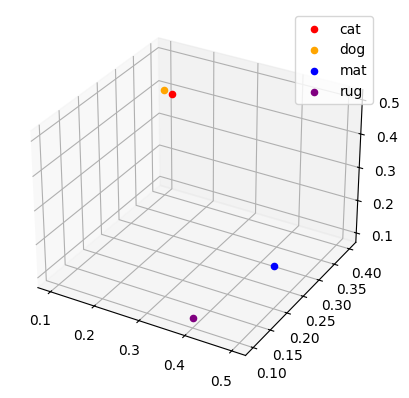

In [12]:
cat = [0.2, 0.3, 0.5]
dog = [0.1, 0.4, 0.4]
mat = [0.5, 0.2, 0.2]
rug = [0.4, 0.1, 0.1]

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(cat[0], cat[1], cat[2], c='r', label='cat')
ax.scatter(dog[0], dog[1], dog[2], c='orange', label='dog')
ax.scatter(mat[0], mat[1], mat[2], c='b', label='mat')
ax.scatter(rug[0], rug[1], rug[2], c='purple', label='rug')
plt.legend()

In [13]:
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import Lowercase
from tokenizers.trainers import WordLevelTrainer

sentence = "The cat sat on the mat"

# Define a "word level" tokenizer split on whitespace.
# Also convert everything to lowercase
tokenizer = Tokenizer(WordLevel(unk_token="[UNK]"))
tokenizer.normalizer = Lowercase()
tokenizer.pre_tokenizer = Whitespace()

# Small vocab for demonstration purposes
trainer = WordLevelTrainer(vocab_size=100, special_tokens=["[PAD]", "[UNK]"])
tokenizer.train_from_iterator([sentence], trainer=trainer)

# Set a fixed-size output
out_size = 8
tokenizer.enable_padding(pad_id=0, pad_token="[PAD]", length=out_size)
tokenizer.enable_truncation(max_length=out_size)

print(tokenizer.get_vocab())

{'[PAD]': 0, 'on': 5, 'cat': 3, 'mat': 4, 'sat': 6, '[UNK]': 1, 'the': 2}


In [14]:
# Process the sentence with the tokenizer
print(tokenizer.encode(sentence).ids)

# Now try a new sentence
new_sentence = "The dog sat on the rug"
print(tokenizer.encode(new_sentence).ids)

[2, 3, 6, 5, 2, 4, 0, 0]
[2, 1, 6, 5, 2, 1, 0, 0]


/tmp/ipykernel_294745/2876092405.py:3: RuntimeWarning: divide by zero encountered in divide
  z_scaled = z / T
/tmp/ipykernel_294745/2876092405.py:4: RuntimeWarning: invalid value encountered in divide
  return np.exp(z_scaled) / np.exp(z_scaled).sum()


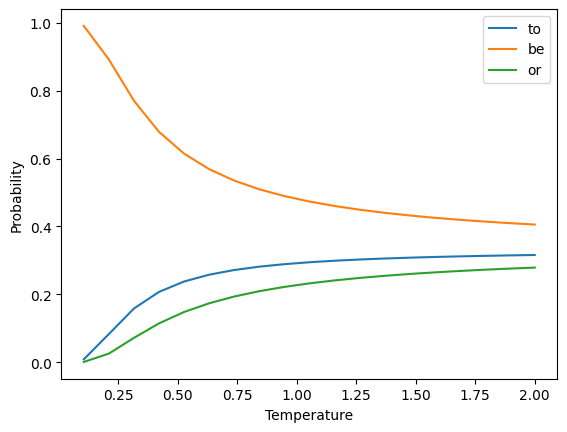

In [15]:
# Softmax plus temperature
def softmax_temp(z: np.ndarray, T: float):
    z_scaled = z / T
    return np.exp(z_scaled) / np.exp(z_scaled).sum()

logits = np.array([2.5, 3.0, 2.25])
temp = np.linspace(0, 2, 20)
probs = np.array([softmax_temp(logits, t) for t in temp])
plt.plot(temp, probs)
plt.xlabel("Temperature")
plt.ylabel("Probability")
plt.legend(["to", "be", "or"])